# Breakup CDCC in $^{8}$B+$^{208}$Pb at 83 MeV/u

We will adapt [this example from the Frescox documentation](https://www.fresco.org.uk/examples/B3-example-br-long.in), which only models $s$-wave breakup. 

From the documentation:

> Breakup calculations can be modeled as single-particle excitation into the continuum. In this example we show a typical CDCC calculation. It calculates the breakup of 8B into p + 7Be, under the field of 208Pb at intermediate energies. [...] The breakup of 8B has been measured many  times with the aim of extracting the proton capture rate on 7Be

Note, that even when neglecting couplings with $l >0$, the CDCC caclulation will already take a minute or so to run! For production use, expensive calculations like this would be better performed using [{{{bfrescoxpro}}}](https://bfrescox.readthedocs.io/en/latest/advanced_users.html), which allows MPI and OpenMP parallelization.

In [1]:
import inspect
import json
import os
import shutil
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

with open("MatplotlibEsthetics.json", "r") as fptr:
    esthetics = json.load(fptr)

plt.style.use(esthetics["style"])
FONTSIZE = esthetics["fontsize"]
TICK_FONTSIZE = esthetics["tick_fontsize"]
MARKERSIZE = esthetics["markersize"]
LINEWIDTH = esthetics["linewidth"]

## BfrescoxPro

CDCC calculations are expensive. For this reason, we will use {{{Bfrescoxpro}}}, to enable parallelization with MPI. For more information, [see the docs](https://bfrescox.readthedocs.io/en/latest/advanced_users.html).

In [2]:
import bfrescox

bfrescox.information()

{'supports_mpi': False,
 'supports_openmp': False,
 'supports_lapack': False,
 'supports_corex': False,
 'frescox_exe': PosixPath('/home/beyerk/Projects/Bfrescox/bfrescox_pypkg/src/bfrescox/bin/frescox')}

In [3]:
EXAMPLE_DIR = Path("./Breakup_template//")
TEMPLATE_FILE_PATH = Path(EXAMPLE_DIR / "B3-example-br.template")
INPUT_FILE_PATH = Path(EXAMPLE_DIR / "B3-example-br-long.in")

## Let's run the input file exactly as is from the website

In [4]:
with open(INPUT_FILE_PATH, "r") as temp:
    input_file = temp.read()

print("Frescox input file from https://www.fresco.org.uk/examples/B5-example-br.in:")
print("-----------------------------------")
print(input_file)

Frescox input file from https://www.fresco.org.uk/examples/B5-example-br.in:
-----------------------------------
CDCC 8B+208Pb ; nuclear and coulomb s-waves                                                    
NAMELIST
 &Fresco  hcm= 0.01 rmatch= -60.000 rintp=  0.15 rsp=   0.0
     rasym=  1000.00 accrcy= 0.0010000 
     jtmin=   0.0 jtmax=   9000.0 absend=  -50.0000 
      jump =       1      10      50     200     
      jbord=     0.0   200.0   300.0  1000.0  9000.0   
     thmin=  0.00 thmax=  20.00 thinc=  0.05  cutr=-20.00
     ips= 0.0000  it0= 0 iter=  0 iblock= 21 nnu= 24
     smallchan= 1.00E-12  smallcoup= 1.00E-12
     chans= 1 smats= 2 xstabl= 1 cdcc= 1
     elab=   656.0000    pel=1 exl=1 lab=1 lin=1 lex=1 /

 &Partition namep='8B      ' massp=  8.0000 zp=  5 nex= 21 pwf=T                
            namet='208Pb   ' masst=208.0000 zt= 82 qval=  0.1370/               
 &States jp= 1.5 ptyp=-1 ep=  0.0000  cpot=  1                                  
         jt= 0.0 ptyt= 1

In [5]:
energy_bins = np.array(
    [
        0.1583,
        0.2180,
        0.3260,
        0.4830,
        0.6889,
        0.9438,
        1.2478,
        1.6007,
        2.0027,
        2.4536,
        2.9536,
        3.5025,
        4.1005,
        4.7474,
        5.4434,
        6.1884,
        6.9824,
        7.8253,
        8.7173,
        9.6583,
    ]
)

In [6]:
# Create the frescox input file by filling in the user-defined template with parameters
cfg = bfrescox.Configuration.from_template(
    INPUT_FILE_PATH,
    EXAMPLE_DIR.joinpath("frescox.in"),
    {},
    overwrite=True,
)

In [7]:
%%time
bfrescox.run_simulation(
    cfg, EXAMPLE_DIR.joinpath("frescox.out"), cwd=EXAMPLE_DIR, overwrite=True
)

CPU times: user 3.55 ms, sys: 2.26 ms, total: 5.81 ms
Wall time: 1min 46s


In [8]:
results = bfrescox.parse_fort16(EXAMPLE_DIR.joinpath("fort.16"))
results.keys()

dict_keys(['channel_1', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_6', 'channel_7', 'channel_8', 'channel_9', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_20', 'channel_21'])

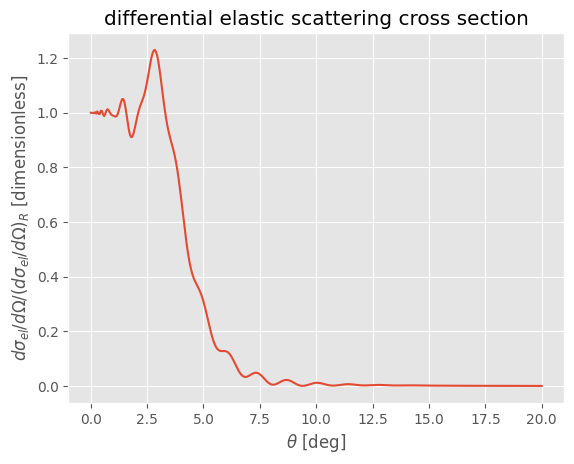

In [9]:
fig, ax = plt.subplots()

plt.plot(results["channel_1"]["Theta_deg"], results["channel_1"]["sigma_mb_sr"])

ax.set_xlabel(r"$\theta$ [deg]")
ax.set_ylabel(r"$d\sigma_{el}/d\Omega / (d\sigma_{el}/d\Omega)_R$ [dimensionless]")
ax.set_title(r"differential elastic scattering cross section")
plt.show()

In [21]:
# get breakup channels (elastic is always channel 1)
br_channels = dict([(k, results[k]) for k in results.keys() if k != "channel_1"])

In [26]:
dsigma_dOmega = np.zeros((len(br_channels), len(results["channel_1"]["Theta_deg"])))
for i, key in enumerate(br_channels):
    theta = np.array(np.deg2rad(results[key]["Theta_deg"]))
    dsigma_dOmega[i, :] = results[key]["sigma_mb_sr"]

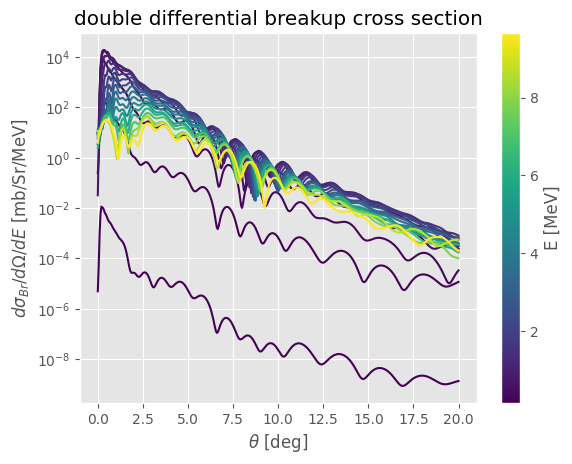

In [27]:
fig, ax = plt.subplots()
# Choose colormap and normalization
cmap = plt.get_cmap("viridis")
norm = mpl.colors.Normalize(vmin=energy_bins.min(), vmax=energy_bins.max())

for i in range(dsigma_dOmega.shape[0]):
    plt.semilogy(
        np.rad2deg(theta), dsigma_dOmega[i, :], color=cmap(norm(energy_bins[i]))
    )

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("E [MeV]")

ax.set_xlabel(r"$\theta$ [deg]")
ax.set_ylabel(r"$d\sigma_{Br}/d\Omega / dE$ [mb/Sr/MeV]")
ax.set_title("double differential breakup cross section")
plt.show()

Integrating over solid angle, we get the differential breakup cross section with respect to energy:

In [31]:
x = theta[None, :]
dsigma_br_dE = (
    2
    * np.pi
    * np.trapezoid(dsigma_dOmega * np.sin(x), x, axis=1)[1:]
    / np.diff(energy_bins)
)

(0.0, 10.0)

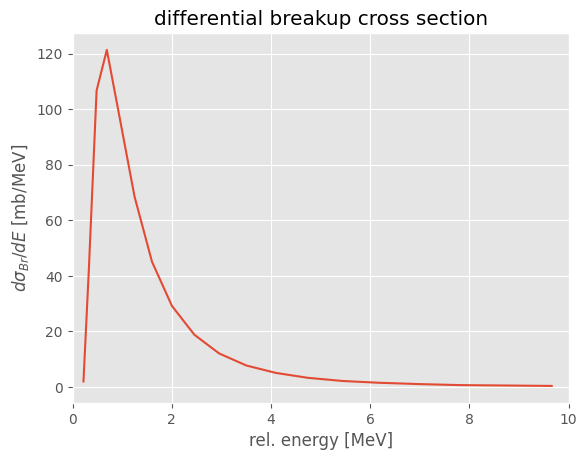

In [32]:
fig, ax = plt.subplots()
ax.set_xlabel(r"rel. energy [MeV]")
ax.set_ylabel(r"$d\sigma_{Br}/dE$ [mb/MeV]")
ax.set_title("differential breakup cross section")

ax.plot(energy_bins[1:], dsigma_br_dE)
ax.set_xlim([0, 10])

Integrating over all energies, we get the breakup differential cross section with respect to angle:

In [35]:
dsigma_br_dOmega = np.sum(dsigma_dOmega, axis=0) / 1000

(0.0, 5.0)

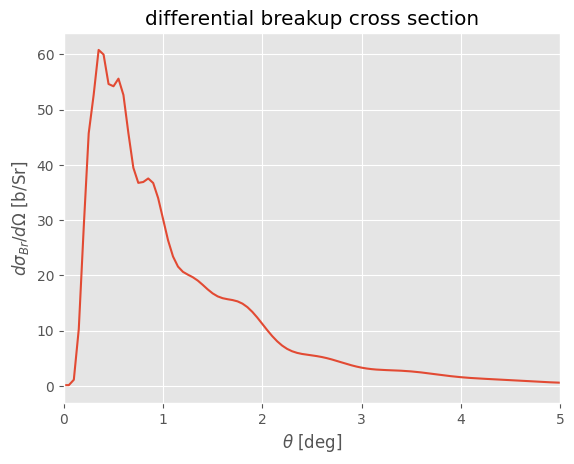

In [36]:
fig, ax = plt.subplots()
ax.set_xlabel(r"$\theta$ [deg]")
ax.set_ylabel(r"$d\sigma_{Br}/d\Omega$ [b/Sr]")
ax.set_title("differential breakup cross section")

ax.plot(np.rad2deg(theta), dsigma_br_dOmega)
ax.set_xlim([0, 5])